In [40]:
include("PermBasis.jl")
include("PlotSetup.jl")
using PyPlot



meanfield_reduced! (generic function with 1 method)

# Check Monte Carlo against rate equation simulation

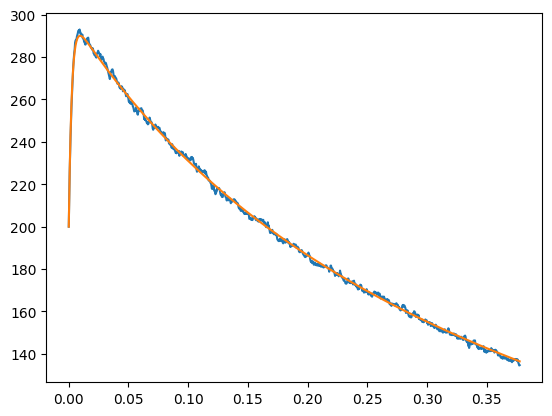

1-element Vector{PyObject}:
 PyObject <matplotlib.lines.Line2D object at 0x14cb77cb0>

In [3]:
Jmax = 100
N = 2 * Jmax
params = Dict("global_decay" => 1.0, "global_pump" => 0.0, "local_pump" => 0.0, "local_dephasing" => 3.0 * N, "local_decay" => 0.0 * N)

basis, index_mapping, Q, nstates = set_up_rate_matrix(Jmax, params)
p0 = initial_state(index_mapping, (Jmax, Jmax), nstates)

function f!(u, p, t)
    return Q * u
end

tmax = 2.0 / log(N)
prob = ODEProblem(f!, p0, (0.0, tmax), dt = 0.001)
sol = solve(prob, RK4())   # or Tsit5(), etc.


intens_rate = expval_I.(sol.u, Ref(index_mapping))
t_rate = sol.t


N_traj = 10000
s_vals = Int.(round.(svals(N)))
m_vals = Int.(round.(mvals(N)))
s_map = Dict(s_vals .=> 1:length(s_vals))
m_map = Dict(m_vals .=> 1:length(m_vals))
p_sm = zeros(length(s_vals), length(m_vals))


times_mc, intens_mc = simulate_ensemble(N, params["global_decay"], params["local_dephasing"], params["local_decay"], tmax, (S, M, N, Γ, ξ) -> (S+M) * (S-M+1), N_traj)

plot(times_mc[1:end], intens_mc[1:end])
plot(t_rate, intens_rate)


# Meaning that it tends to fail for the independent emission part, but the predictions for the maximum intensity are actually still correct

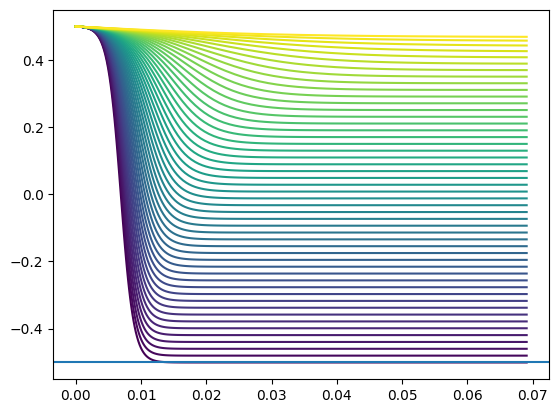

PyObject <matplotlib.lines.Line2D object at 0x35d013a10>

In [100]:

N = 1000
tmax = 10.0 * log(N) / N
cs = [viridis((i - 1) / (50 - 1)) for i in 1:50] 


for (i,r) in enumerate(range(0.0, 1.0, 50))
    p = [1.0, r * N, N, 0.0 * N / log(N)]
    u0 = [1/N, 1/2]
    prob = ODEProblem(meanfield_reduced!, u0, (0.0, tmax), p)
    mfsol = solve(prob, AutoTsit5(Rosenbrock23()), reltol=1e-8, abstol=1e-8)
    plot(mfsol.t, map(x->x[2], mfsol.u), label = r, color = cs[i])
end
#legend()
axhline(- 0.5)

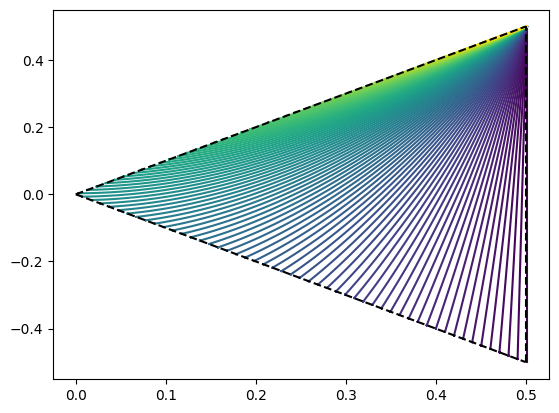

1-element Vector{PyObject}:
 PyObject <matplotlib.lines.Line2D object at 0x359dcecf0>

In [97]:
rs = range(0.0, 1.0, 100)
viridis = get_cmap("viridis")
n_colors = length(rs)
cs = [viridis((i - 1) / (n_colors - 1)) for i in 1:n_colors] 

for (i,r) in enumerate(rs)
    N = 1000
    tmax = 20.0 * log(N) / N

    p = [1.0, r * N, N, 0.0 * N / log(N)]
    u0 = [1/N, 1/2]
    prob = ODEProblem(meanfield_reduced!, u0, (0.0, tmax), p)
    mfsol = solve(prob, AutoTsit5(Rosenbrock23()), reltol=1e-8, abstol=1e-8)
    Ms = map(x->x[2], mfsol.u)
    Is = map(x->x[1], mfsol.u)
    Ss = sqrt.(Is .+ Ms.^2)
    plot(Ss, Ms, color = cs[i])
end

Sgrid = range(0.0, 0.5, length=400)
plot(Sgrid,  Sgrid, "k--", linewidth=1.5)
plot(Sgrid, -Sgrid, "k--", linewidth=1.5)
plot([0.5, 0.5], [-0.5, 0.5], "k--", linewidth=1.5)

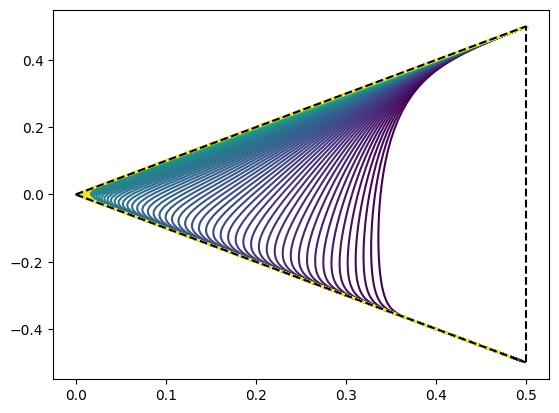

1-element Vector{PyObject}:
 PyObject <matplotlib.lines.Line2D object at 0x35c1b5d30>

In [99]:
rs = range(0.0, 1.0, 100)
viridis = get_cmap("viridis")
n_colors = length(rs)
cs = [viridis((i - 1) / (n_colors - 1)) for i in 1:n_colors] 

for (i,r) in enumerate(rs)
    N = 1000
    tmax = 20.0 * log(N) / N

    p = [1.0, r * N, N, 0.2 * N / log(N)]
    u0 = [1/N, 1/2]
    prob = ODEProblem(meanfield_reduced!, u0, (0.0, tmax), p)
    mfsol = solve(prob, AutoTsit5(Rosenbrock23()), reltol=1e-8, abstol=1e-8)
    Ms = map(x->x[2], mfsol.u)
    Is = map(x->x[1], mfsol.u)
    Ss = sqrt.(Is .+ Ms.^2)
    plot(Ss, Ms, color = cs[i])
end

Sgrid = range(0.0, 0.5, length=400)
plot(Sgrid,  Sgrid, "k--", linewidth=1.5)
plot(Sgrid, -Sgrid, "k--", linewidth=1.5)
plot([0.5, 0.5], [-0.5, 0.5], "k--", linewidth=1.5)

In [7]:

N = 5000
N_traj = 4000
rs = range(0.0, 1.5, 50)
gs = range(0.0, 0.5, 50)
mf_data = zeros(length(rs), length(gs))
mc_data = zeros(length(rs), length(gs))

for (i,r) in enumerate(rs)
    for (j,g) in enumerate(gs)
        params = Dict("global_decay" => 1.0, "global_pump" => 0.0, "local_pump" => 0.0, "local_dephasing" => r * N, "local_decay" => g * N / log(N))
        imc, imf = mc_vs_mf_data(N, params, N_traj; time_factor = 8.0)
        mf_data[i,j] = imf
        mc_data[i,j] = imc
    end
end

LoadError: invalid assignment to constant Main.mc_data. This redefinition may be permitted using the `const` keyword.

# You have the standard mistake that meanfield gives you 1/4 for Dicke, which is not asymptotically correct. Aside from that the result of the mean field is representative

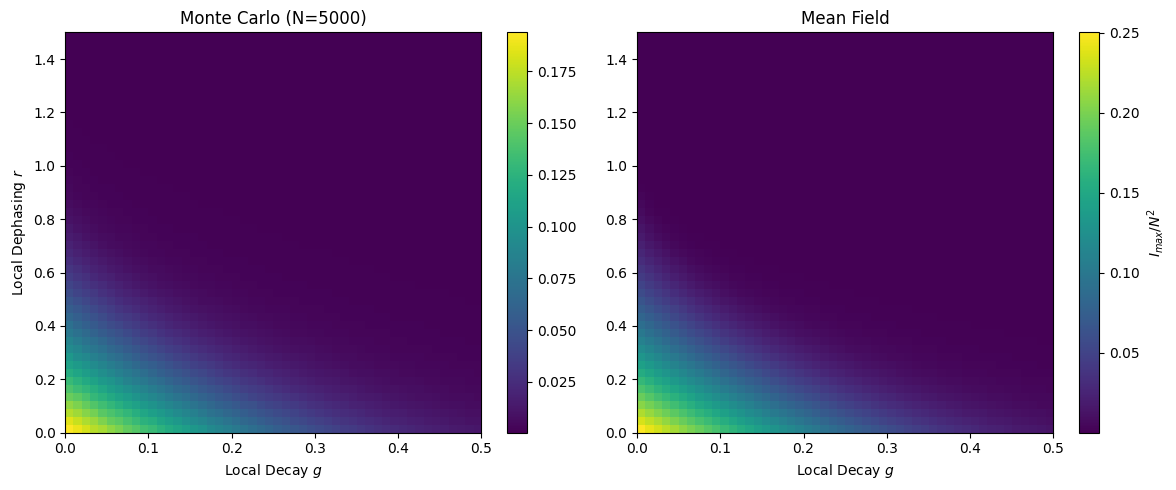

In [ ]:
using PyPlot

# Define extent based on your ranges
ext = [minimum(gs), maximum(gs), minimum(rs), maximum(rs)]

fig, axs = plt.subplots(1, 2, figsize=(12, 5))

# Monte Carlo Plot
im1 = axs[1].imshow(mc_data / N^2, extent=ext, origin="lower", aspect="auto", cmap="viridis")
axs[1].set_title("Monte Carlo (N=$N)")
axs[1].set_xlabel(L"Local Decay $g$")
axs[1].set_ylabel(L"Local Dephasing $r$")
colorbar(im1, ax=axs[1])

# Mean Field Plot
im2 = axs[2].imshow(mf_data, extent=ext, origin="lower", aspect="auto", cmap="viridis")
axs[2].set_title("Mean Field")
axs[2].set_xlabel(L"Local Decay $g$")
colorbar(im2, ax=axs[2], label=L"I_{max} / N^2")

tight_layout()

display(gcf())
close("all")

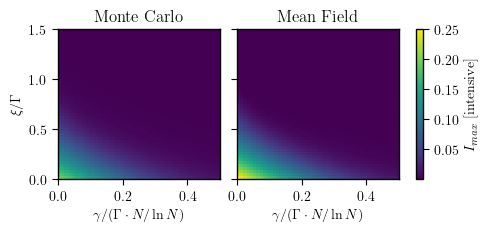

In [ ]:
using PyPlot

wt, ht = latex_plot_setup()


# Normalization
mc_norm = mc_data ./ N^2
mf_norm = mf_data 

# Global limits for shared colorbar
v_min = min(minimum(mc_norm), minimum(mf_norm))
v_max = max(maximum(mc_norm), maximum(mf_norm))

# Setup figure with constrained_layout to fix colorbar placement
fig, axs = plt.subplots(1, 2, figsize = (2 * wt, 1.5 * ht), sharey=true, constrained_layout=true)
ext = [gs[1], gs[end], rs[1], rs[end]]

# Subplot 1: Monte Carlo
im1 = axs[1].imshow(mc_norm, extent=ext, origin="lower", aspect="auto", 
                    vmin=v_min, vmax=v_max, cmap="viridis")
axs[1].set_title("Monte Carlo")
axs[1].set_ylabel(L"$\xi / \Gamma$")
axs[1].set_xlabel(L"$\gamma / (\Gamma \cdot N / \ln N)$")

# Subplot 2: Mean Field
im2 = axs[2].imshow(mf_norm, extent=ext, origin="lower", aspect="auto", 
                    vmin=v_min, vmax=v_max, cmap="viridis")
axs[2].set_title("Mean Field")
axs[2].set_xlabel(L"$\gamma / (\Gamma \cdot N / \ln N)$")

# Add a single colorbar to the right of both subplots
cb = fig.colorbar(im1, ax=axs, location="right")
cb.set_label(L"$I_{max}$ [intensive]")
savefig("../data/mean_field_vs_MC.pdf", bbox_inches = "tight")
display(gcf())

In [9]:
Ns = [1000, 10000, 50000]
N_traj = 500
rs = range(0.0, 2.0, 300)
mf_itens = zeros(length(rs), length(Ns))
mc_intens = zeros(length(rs), length(Ns))
mf_t = zeros(length(rs), length(Ns))
mc_t = zeros(length(rs), length(Ns))

g = 0.0

for (i,r) in enumerate(rs)
    for (j,N) in enumerate(Ns)
        params = Dict("global_decay" => 1.0, "global_pump" => 0.0, "local_pump" => 0.0, "local_dephasing" => r * N, "local_decay" => g * N / log(N))
        imc, imf, tmc, tmf = mc_vs_mf_data(N, params, N_traj; time_factor = 8.0)
        mf_itens[i,j] = imf
        mc_intens[i, j] = imc
        mf_t[i,j] = tmf
        mc_t[i, j] = tmc
    end
end

In [7]:
function sci_label(N)
    exp = floor(Int, log10(N))
    mant = N / 10.0^exp

    # if mantissa is (numerically) an integer → print as Int
    if isapprox(mant, round(mant); atol=1e-12)
        mant_str = string(Int(round(mant)))
    else
        mant_str = string(mant)
    end

    return "\$N=$(mant_str)\\times 10^{$exp}\$"
end

sci_label (generic function with 1 method)

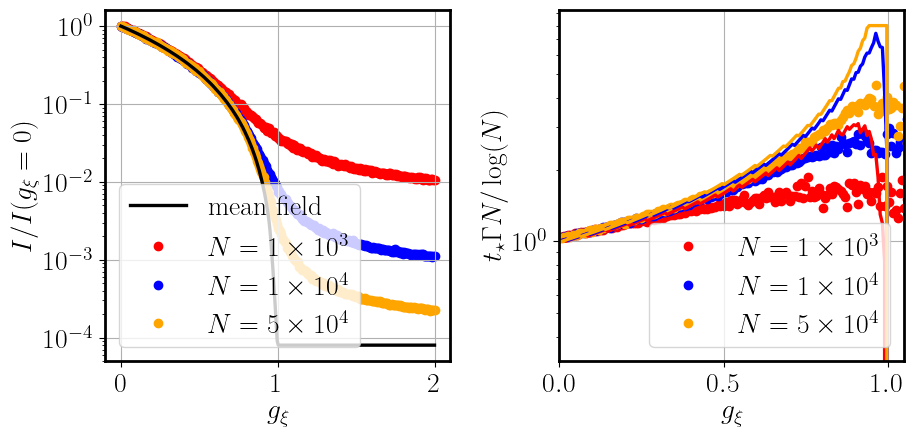

In [11]:
width, height = latex_plot_setup(scale = 2.0, ratio = 1)
fig, axes = subplots(ncols = 2, figsize = (2 * width, height))

sca(axes[1])
plot(rs, (mf_itens[:,end]) * 4, color = "k", label = "mean field")
#plot(rs, (1.0 .- rs) .^ 2, color = "k", label = "mean field")
for j=1:length(Ns)
    scatter(rs, (mc_intens[:,j]) / mc_intens[1,j], label = sci_label(Ns[j]),)
end

yscale("log")
ylabel(L"I/I(g_\xi=0)")
xlabel(L"g_\xi")
grid()
legend()

cs = ["red", "blue", "orange"]

sca(axes[2])
for j=1:length(Ns)
    plot(rs, mf_t[:,j] * Ns[j] / log(Ns[j]), color = cs[j], linestyle = "solid")
    scatter(rs, mc_t[:,j] * Ns[j] / log(Ns[j]), label = sci_label(Ns[j]))
end

xlim(left = 0.0, right = 1.05)
yscale("log")
ylabel(L"t_\star \Gamma N/\log(N)")
xlabel(L"g_\xi")
grid()

legend()

tight_layout()
display(gcf())
close("all")


In [17]:
Ns2 = Int.(round.(10 .^ range(4, 7.0, 30)))
N_traj = 800
rs2 = [0.95, 1.05]
mc_intens2 = zeros(length(rs2), length(Ns2))
mc_t2 = zeros(length(rs2), length(Ns2))
g = 0.0

for (i,r) in enumerate(rs2)
    for (j,N) in enumerate(Ns2)
        println(N)
        params = Dict("global_decay" => 1.0, "global_pump" => 0.0, "local_pump" => 0.0, "local_dephasing" => r * N, "local_decay" => g * N / log(N))
        imc, tmc = mc_data(N, params, N_traj; time_factor = 16.0)
        mc_intens2[i, j] = imc
        mc_t2[i, j] = tmc
    end
end

10000
12690
16103
20434
25929
32903
41753
52983
67234
85317
108264
137382
174333
221222
280722
356225
452035
573615
727895
923671
1172102
1487352
1887392
2395027
3039195
3856620
4893901
6210169
7880463
10000000
10000
12690
16103
20434
25929
32903
41753
52983
67234
85317
108264
137382
174333
221222
280722
356225
452035
573615
727895
923671
1172102
1487352
1887392
2395027
3039195
3856620
4893901
6210169
7880463
10000000


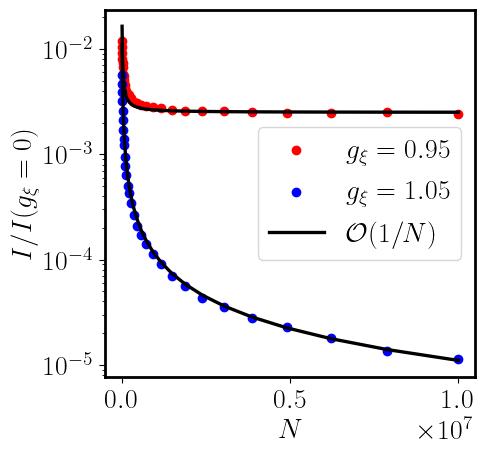

PyObject Text(0.5, 34.600875514563455, '$N$')

In [22]:
for j=1:length(rs2)
    scatter(Ns2, mc_intens2[j,:] ./ Ns2 .^ 2 / 0.2, label = "\$g_\\xi=$(rs2[j])\$")
end

plot(Ns2, 110 ./ Ns2, color = "k", label = L"\mathcal O(1/N)")
plot(Ns2, 140 ./ Ns2 .+ (1-rs2[1])^2, color = "k", linestyle = "solid")

legend()
yscale("log")
ylabel(L"I/I(g_\xi=0)")
xlabel(L"N")


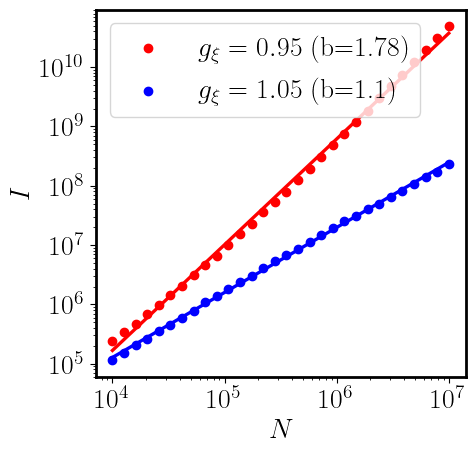

PyObject Text(0.5, 34.600875514563455, '$N$')

In [19]:
using LinearAlgebra

for j=1:length(rs2)

    Is = mc_intens2[j,:]

    # log-log data
    x = log.(Ns2)
    y = log.(Is)

    # linear fit: y = c + b x
    A = [ones(length(x)) x]
    coeff = A \ y
    c, b = coeff

    a = exp(c)

    # plot data
    scatter(Ns2, Is, label = "\$g_\\xi=$(rs2[j])\$ (b=$(round(b, digits=2)))")

    # plot fit
    plot(Ns2, a .* Ns2.^b, linestyle="-")
end

legend()
yscale("log")
xscale("log")
ylabel(L"I")
xlabel(L"N")

In [44]:
import Pkg; Pkg.add("JLD2")

In [42]:
using JLD2

LoadError: ArgumentError: Package JLD2 not found in current path.
- Run `import Pkg; Pkg.add("JLD2")` to install the JLD2 package.

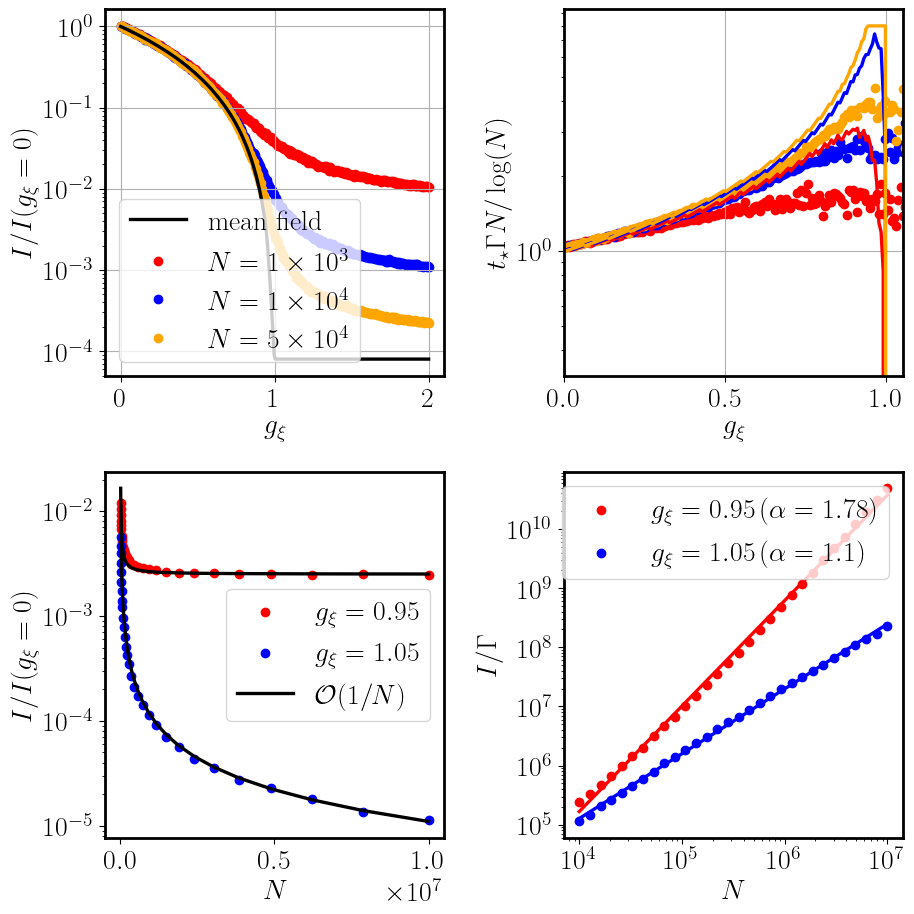

In [41]:
width, height = latex_plot_setup(scale = 2.0, ratio = 1)
fig, axes = subplots(ncols = 2, nrows = 2, figsize = (2 * width, 2 * height))

sca(axes[1])
plot(rs, (mf_itens[:,end]) * 4, color = "k", label = "mean field")
#plot(rs, (1.0 .- rs) .^ 2, color = "k", label = "mean field")
for j=1:length(Ns)
    scatter(rs, (mc_intens[:,j]) / mc_intens[1,j], label = sci_label(Ns[j]),)
end

yscale("log")
ylabel(L"I/I(g_\xi=0)")
xlabel(L"g_\xi")
grid()
legend()

cs = ["red", "blue", "orange"]

sca(axes[3])
for j=1:length(Ns)
    plot(rs, mf_t[:,j] * Ns[j] / log(Ns[j]), color = cs[j], linestyle = "solid")
    scatter(rs, mc_t[:,j] * Ns[j] / log(Ns[j]), label = sci_label(Ns[j]))
end

xlim(left = 0.0, right = 1.05)
yscale("log")
ylabel(L"t_\star \Gamma N/\log(N)")
xlabel(L"g_\xi")
grid()

sca(axes[2])
for j=1:length(rs2)
    scatter(Ns2, mc_intens2[j,:] ./ Ns2 .^ 2 / 0.2, label = "\$g_\\xi=$(rs2[j])\$")
end

plot(Ns2, 110 ./ Ns2, color = "k", label = L"\mathcal O(1/N)")
plot(Ns2, 140 ./ Ns2 .+ (1-rs2[1])^2, color = "k", linestyle = "solid")

legend()
yscale("log")
ylabel(L"I/I(g_\xi=0)")
xlabel(L"N")

sca(axes[4])
for j=1:length(rs2)

    Is = mc_intens2[j,:]

    # log-log data
    x = log.(Ns2)
    y = log.(Is)

    # linear fit: y = c + b x
    A = [ones(length(x)) x]
    coeff = A \ y
    c, b = coeff

    a = exp(c)

    # plot data
    scatter(Ns2, Is, label = "\$g_\\xi=$(rs2[j])\\,(\\alpha=$(round(b, digits=2)))\$")

    # plot fit
    plot(Ns2, a .* Ns2.^b, linestyle="-")
end

legend()
yscale("log")
xscale("log")
ylabel(L"I/\Gamma")
xlabel(L"N")

legend()

tight_layout()
savefig("../data/dephasing_panel.pdf", bbox_inches = "tight")

In [46]:
using JLD2

# save
jldsave("../data/dephasing_panel_data.jld2";
    rs = rs,
    Ns = Ns,
    mf_itens = mf_itens,
    mc_intens = mc_intens,
    mf_t = mf_t,
    mc_t = mc_t,
    rs2 = rs2,
    Ns2 = Ns2,
    mc_intens2 = mc_intens2,
)

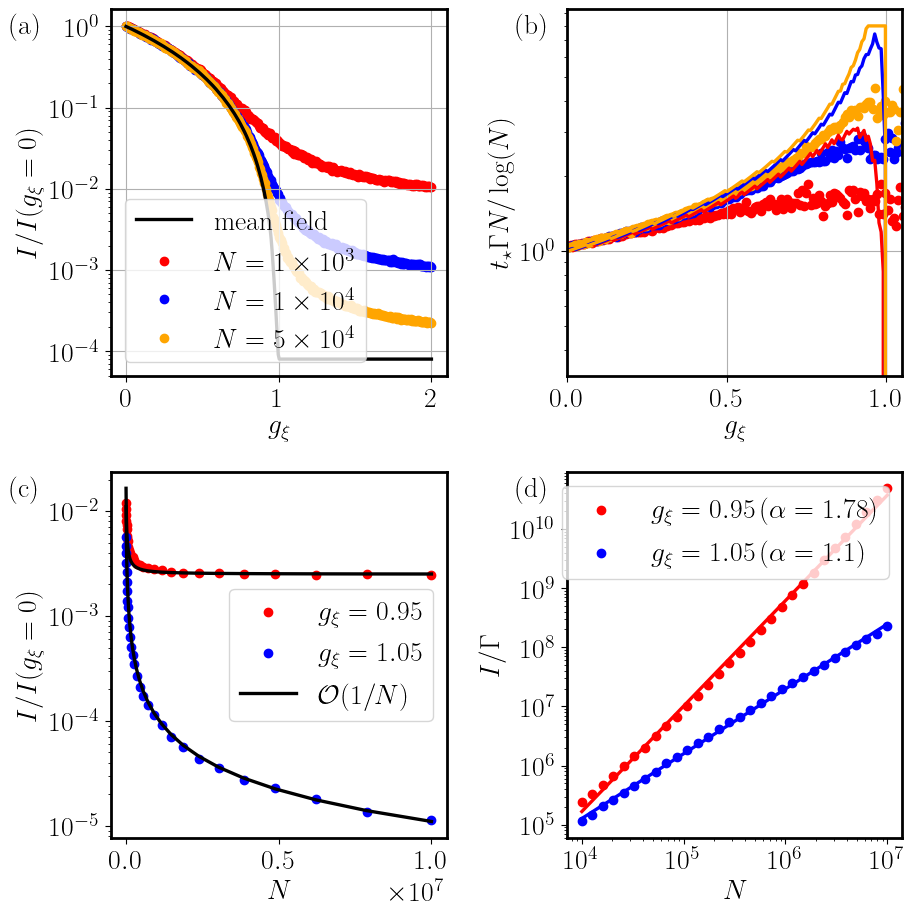

: 

In [ ]:
width, height = latex_plot_setup(scale = 2.0, ratio = 1)
fig, axes = subplots(ncols = 2, nrows = 2, figsize = (2 * width, 2 * height))

sca(axes[1])
plot(rs, (mf_itens[:,end]) * 4, color = "k", label = "mean field")
for j=1:length(Ns)
    scatter(rs, (mc_intens[:,j]) / mc_intens[1,j], label = sci_label(Ns[j]))
end
yscale("log")
ylabel(L"I/I(g_\xi=0)")
xlabel(L"g_\xi")
grid()
legend()

cs = ["red", "blue", "orange"]

sca(axes[3])
for j=1:length(Ns)
    plot(rs, mf_t[:,j] * Ns[j] / log(Ns[j]), color = cs[j], linestyle = "solid")
    scatter(rs, mc_t[:,j] * Ns[j] / log(Ns[j]), label = sci_label(Ns[j]))
end
xlim(left = 0.0, right = 1.05)
yscale("log")
ylabel(L"t_\star \Gamma N/\log(N)")
xlabel(L"g_\xi")
grid()

sca(axes[2])
for j=1:length(rs2)
    scatter(Ns2, mc_intens2[j,:] ./ Ns2 .^ 2 / 0.2, label = "\$g_\\xi=$(rs2[j])\$")
end
plot(Ns2, 110 ./ Ns2, color = "k", label = L"\mathcal O(1/N)")
plot(Ns2, 140 ./ Ns2 .+ (1-rs2[1])^2, color = "k", linestyle = "solid")
legend()
yscale("log")
ylabel(L"I/I(g_\xi=0)")
xlabel(L"N")

sca(axes[4])
for j=1:length(rs2)
    Is = mc_intens2[j,:]
    x = log.(Ns2)
    y = log.(Is)
    A = [ones(length(x)) x]
    coeff = A \ y
    c, b = coeff
    a = exp(c)

    scatter(Ns2, Is, label = "\$g_\\xi=$(rs2[j])\\,(\\alpha=$(round(b, digits=2)))\$")
    plot(Ns2, a .* Ns2.^b, linestyle="-")
end
legend()
yscale("log")
xscale("log")
ylabel(L"I/\Gamma")
xlabel(L"N")

axes[1].text(-0.3, 0.99, "(a)", transform=axes[1].transAxes, va="top", ha="left")
axes[2].text(-0.3, 0.99, "(c)", transform=axes[2].transAxes, va="top", ha="left")
axes[3].text(-0.15, 0.99, "(b)", transform=axes[3].transAxes, va="top", ha="left")
axes[4].text(-0.15, 0.99, "(d)", transform=axes[4].transAxes, va="top", ha="left")

tight_layout()
savefig("../data/dephasing_panel.pdf", bbox_inches = "tight")

In [38]:
Ns2 = Int.(round.(10 .^ range(3, 5, 30)))
N_traj = 800
gs2 = [0.1, 0.3, 0.4]
mc_intens2 = zeros(length(gs2), length(Ns2))
mf_intens2 = zeros(length(gs2), length(Ns2))
mc_t2 = zeros(length(gs2), length(Ns2))
r = 0.0

for (i,g) in enumerate(gs2)
    for (j,N) in enumerate(Ns2)
        println(N)
        params = Dict("global_decay" => 1.0, "global_pump" => 0.0, "local_pump" => 0.0, "local_dephasing" => r * N, "local_decay" => g * N / log(N))
        #imc, tmc = mc_data(N, params, N_traj; time_factor = 16.0)
        imc, imf, tmc, tmf = mc_vs_mf_data(N, params, N_traj; time_factor = 8.0)

        mc_intens2[i, j] = imc
        mf_intens2[i, j] = imf
        mc_t2[i, j] = tmc
    end
end

1000
1172
1374
1610
1887
2212
2593
3039
3562
4175
4894
5736
6723
7880
9237
10826
12690
14874
17433
20434
23950
28072
32903
38566
45204
52983
62102
72790
85317
100000
1000
1172
1374
1610
1887
2212
2593
3039
3562
4175
4894
5736
6723
7880
9237
10826
12690
14874
17433
20434
23950
28072
32903
38566
45204
52983
62102
72790
85317
100000
1000
1172
1374
1610
1887
2212
2593
3039
3562
4175
4894
5736
6723
7880
9237
10826
12690
14874
17433
20434
23950
28072
32903
38566
45204
52983
62102

LoadError: InterruptException:


72790


1
2


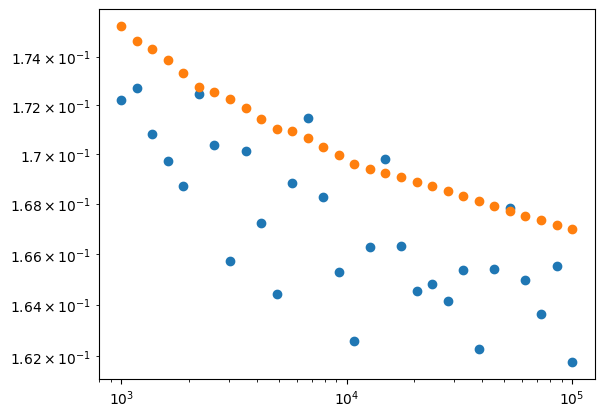

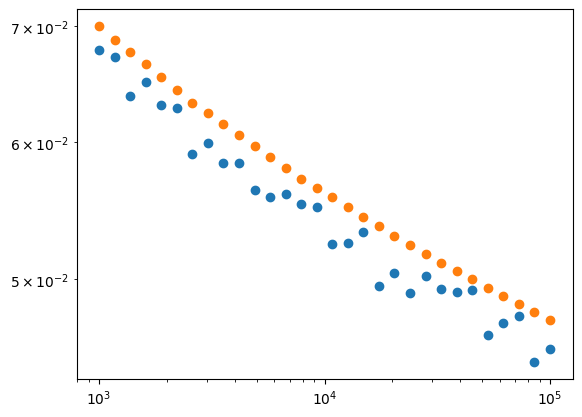

In [ ]:
for j in 1:size(mc_intens2, 1)
    println(j)
    figure()
    scatter(Ns2, mc_intens2[j,:] ./ Ns2 .^ 2 * (1/0.196)/4)
    scatter(Ns2, mf_intens2[j,:])
    #plot(Ns2, mc_t2[1,:])
    yscale("log")
    xscale("log")
end

In [63]:
Ns = [1000, 10000, 50000]
N_traj = 500
gs = range(0.0, 1.0, 300)
mf_itens = zeros(length(gs), length(Ns))
mc_intens = zeros(length(gs), length(Ns))
mf_t = zeros(length(gs), length(Ns))
mc_t = zeros(length(gs), length(Ns))
r = 0.0
g = 0.0

for (i,g) in enumerate(gs)
    for (j,N) in enumerate(Ns)
        params = Dict("global_decay" => 1.0, "global_pump" => 0.0, "local_pump" => 0.0, "local_dephasing" => r * N, "local_decay" => g * N / log(N))
        imc, imf, tmc, tmf = mc_vs_mf_data(N, params, N_traj; time_factor = 8.0)
        mf_itens[i,j] = imf
        mc_intens[i, j] = imc
        mf_t[i,j] = tmf
        mc_t[i, j] = tmc
    end
end

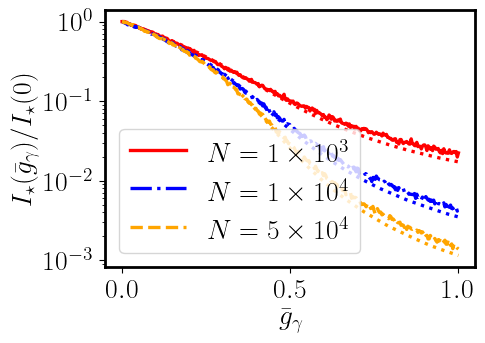

In [119]:
width, height = latex_plot_setup(scale = 2.0, ratio = 0.7)
figure(figsize = (width, height))

cs = ["red", "blue", "orange"]
for j in 1:size(mf_itens, 2)
    plot(gs, mc_intens[:,j] / mc_intens[1,j], color = cs[j], label = sci_label(Ns[j]))
    plot(gs, mf_itens[:,j] / mf_itens[1,j], color = cs[j], linestyle = "dotted")
end
yscale("log")
xlabel(L"\bar g_\gamma")
ylabel(L"I_\star(\bar g_\gamma)/ I_\star(0)")
legend()
savefig("../data/mean_field_spont.pdf", bbox_inches = "tight")